In [1]:
import bilby
import numpy as np
import matplotlib.pyplot as plt
from Packages.initial_mass_function import TaperedPowerLaw

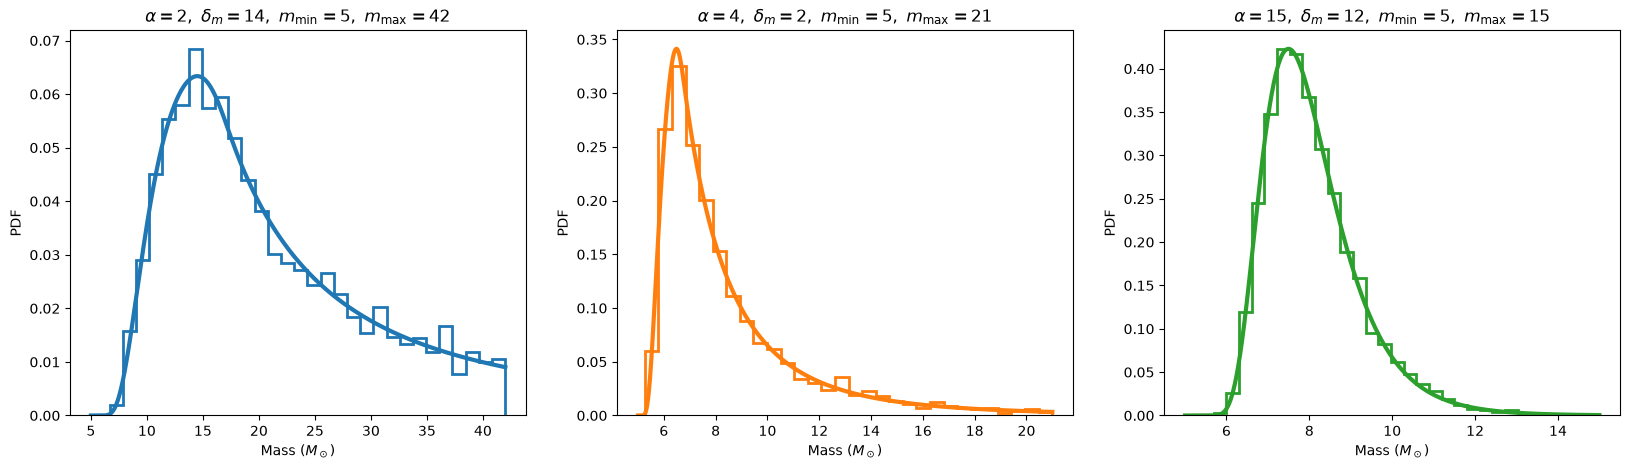

In [2]:
kwargs_list = [
    {"alpha": 2, "delta_m": 14, "minimum": 5, "maximum": 42},
    {"alpha": 4, "delta_m": 2, "minimum": 5, "maximum": 21},
    {"alpha": 15, "delta_m": 12, "minimum": 5, "maximum": 15}
]

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20, 5))

for i, kwargs in enumerate(kwargs_list):
    mass_prior = TaperedPowerLaw(**kwargs)
    masses = mass_prior.sample(5000)

    label = (
        rf"$\alpha={kwargs['alpha']},\ "
        rf"\delta_m={kwargs['delta_m']},\ "
        rf"m_{{\min}}={kwargs['minimum']},\ "
        rf"m_{{\max}}={kwargs['maximum']}$"
    )

    ax[i].hist(masses, bins=30, density=True, histtype="step", linewidth=2, color=f"C{i}")

    ax[i].plot(mass_prior.mass_grid, mass_prior.pdf_grid, linewidth=3, color=f"C{i}")
    ax[i].set_title(label)
    ax[i].set_xlabel(r"Mass ($M_\odot$)")
    ax[i].set_ylabel("PDF")

plt.show()